In [ ]:
import pandas as pd
df = pd.read_excel('Store_Sales.xlsx')
df

,Order Priority,Customer ID,Customer Name,Customer Segment,Product Container,Product Name,Country,Location,City,Order Date,Quantity ordered new,Order ID
0,High,3,Bonnie Potter,Corporate,Wrap Bag,SANFORD Liquid Accent™ Tank-Style Highlighters,United States,West:Washington,Anacortes,2015-01-07,4,88522
1,Not Specified,5,Ronnie Proctor,Home Office,Jumbo Drum,Global Troy™ Executive Leather Low-Back Tilter,United States,West:California,San Gabriel,2015-06-13,12,90193
2,Critical,11,Marcus Dunlap,Home Office,Small Pack,"DAX Two-Tone Rosewood/Black Document Frame, De...",United States,East:New Jersey,Roselle,2015-02-15,22,90192
3,Medium,14,Gwendolyn F Tyson,Small Business,Small Box,Howard Miller 12-3/4 Diameter Accuwave DS ™ Wa...,United States,Central:Minnesota,Prior Lake,2015-05-12,16,86838
4,Medium,14,Gwendolyn F Tyson,Small Business,Wrap Bag,Newell 321,United States,Central:Minnesota,Prior Lake,2015-05-12,7,86838
...,...,...,...,...,...,...,...,...,...,...,...,...
94,Low,166,Vicki Hauser,Consumer,Jumbo Box,Okidata ML320 Series Turbo Dot Matrix Printers,United States,South:Tennessee,Lebanon,2015-01-11,5,89426
95,Low,169,Janice Cole,Corporate,Small Box,"Fellowes Mobile Numeric Keypad, Graphite",United States,South:Louisiana,Baton Rouge,2015-01-03,3,87463
96,Low,169,Janice Cole,Corporate,Large Box,Polycom ViaVideo™ Desktop Video Communications...,United States,South:Louisiana,Baton Rouge,2015-01-03,12,87463
97,Low,169,Janice Cole,Corporate,Wrap Bag,"Staples Wirebound Steno Books, 6"" x 9"", 12/Pack",United States,South:Louisiana,Baton Rouge,2015-01-03,3,87463


In [ ]:
#Info of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order Priority        99 non-null     object        
 1   Customer ID           99 non-null     int64         
 2   Customer Name         99 non-null     object        
 3   Customer Segment      99 non-null     object        
 4   Product Container     99 non-null     object        
 5   Product Name          99 non-null     object        
 6   Country               99 non-null     object        
 7   Location              99 non-null     object        
 8   City                  99 non-null     object        
 9   Order Date            99 non-null     datetime64[ns]
 10  Quantity ordered new  99 non-null     int64         
 11  Order ID              99 non-null     int64         
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 9.4+ KB


In [ ]:
df.groupby(by = 'Customer Segment')['Quantity ordered new'].count()

Customer Segment
Consumer          13
Corporate         37
Home Office       25
Small Business    24
Name: Quantity ordered new, dtype: int64

In [ ]:
df['Order Priority'].value_counts()

High             28
Medium           25
Not Specified    19
Low              15
Critical         12
Name: Order Priority, dtype: int64

In [ ]:
df[(df['Order Priority'].isin(['High', 'Critical'])) & (df['Customer Segment'] == 'Home Office')]['Customer Segment'].count()

9

In [ ]:
df['Year'] = df['Order Date'].dt.year
df
df[df['Year'] == 2015]['Quantity ordered new'].count()

99

In [ ]:
#year (Jan - March), (April - June), (July - Sept), (Oct - Dec)
df['Month'] = df['Order Date'].dt.month
df
df[df['Month'].isin([1,2,3])]['Quantity ordered new'].count()

46

In [ ]:
df[(df['Year'] == 2015) & (df['Month'] == 6)]['Quantity ordered new'].count()

13

In [ ]:
cond = df.head(50)
#cond = df.iloc[0:50]
cond[cond['City'] == 'Prior Lake']

,Order Priority,Customer ID,Customer Name,Customer Segment,Product Container,Product Name,Country,Location,City,Order Date,Quantity ordered new,Order ID,Year,Month
3,Medium,14,Gwendolyn F Tyson,Small Business,Small Box,Howard Miller 12-3/4 Diameter Accuwave DS ™ Wa...,United States,Central:Minnesota,Prior Lake,2015-05-12,16,86838,2015,5
4,Medium,14,Gwendolyn F Tyson,Small Business,Wrap Bag,Newell 321,United States,Central:Minnesota,Prior Lake,2015-05-12,7,86838,2015,5
5,Medium,14,Gwendolyn F Tyson,Small Business,Wrap Bag,Newell 351,United States,Central:Minnesota,Prior Lake,2015-05-12,4,86838,2015,5
6,Medium,14,Gwendolyn F Tyson,Small Business,Wrap Bag,"OIC Colored Binder Clips, Assorted Sizes",United States,Central:Minnesota,Prior Lake,2015-05-12,4,86838,2015,5


In [ ]:
cond = df.head(-20)
cond[cond['Product Container'] == 'Wrap Bag'].count()

Order Priority          17
Customer ID             17
Customer Name           17
Customer Segment        17
Product Container       17
Product Name            17
Country                 17
Location                17
City                    17
Order Date              17
Quantity ordered new    17
Order ID                17
Year                    17
Month                   17
dtype: int64

<Axes: xlabel='Order Priority', ylabel='Order Date'>

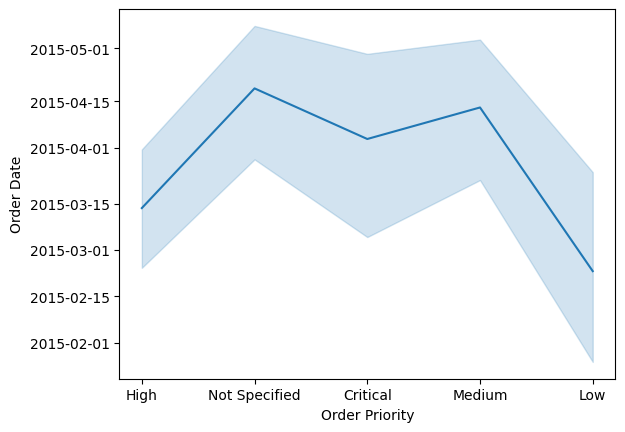

In [ ]:
import seaborn as sns
sns.lineplot(x = df['Order Priority'], y = df['Order Date'])

<Axes: xlabel='Order Priority', ylabel='Quantity ordered new'>

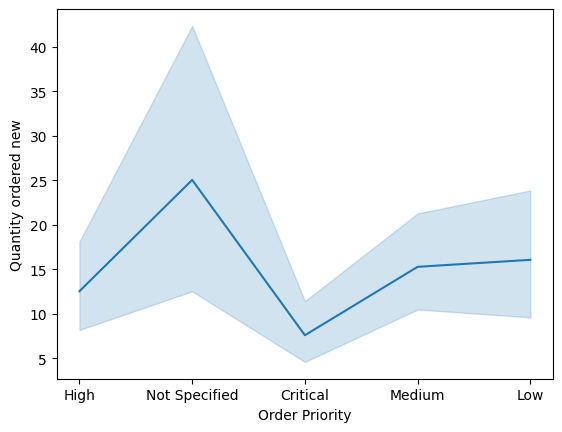

In [ ]:
sns.lineplot(x = df['Order Priority'], y = df['Quantity ordered new'])

<Axes: xlabel='Order Priority', ylabel='Order Date'>

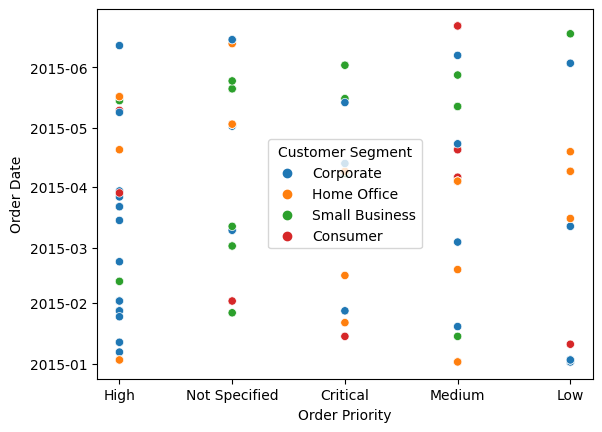

In [ ]:
sns.scatterplot(x = df['Order Priority'], y = df['Order Date'], hue = df['Customer Segment'])